# Importing files

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Selecting Device

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Train Dataset and Dataloader

In [9]:
batch_size = 128
data_transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root="./data", train= True, transform=data_transform, download=True)
train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)

# Model Definition

In [10]:
class AutoEncoder(nn.Module):

  def __init__(self, latent_dim = 64, hidden_dim = 256):
    super().__init__()
    #Encoder
    self.encoder = nn.Sequential(
        nn.Linear(784, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, latent_dim),
        nn.ReLU()
    )

    #Decoder
    self.decoder = nn.Sequential(
        nn.Linear(latent_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, 784),
        nn.Sigmoid()
    )

  def forward(self, x):
    z = self.encoder(x)
    x_recons = self.decoder(z)
    return x_recons

In [11]:
model = AutoEncoder()
criterion  = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 1e-3)
model = model.to(device)

# Training

In [12]:
epochs = 20

model.train()
for epoch in range(epochs):
  total_loss = 0
  for x, _ in train_loader:
    x = x.view(-1, 784).to(device)
    optimizer.zero_grad()
    x_recons = model(x)
    loss = criterion(x_recons, x)
    loss.backward()
    optimizer.step()

    total_loss = total_loss + loss.item()

  avg_loss = total_loss/len(train_loader)

  print(f"Epoch : [{epoch + 1}/{epochs}] Loss : {avg_loss:.6f}")

Epoch : [1/20] Loss : 0.042805
Epoch : [2/20] Loss : 0.016430
Epoch : [3/20] Loss : 0.012104
Epoch : [4/20] Loss : 0.010009
Epoch : [5/20] Loss : 0.008836
Epoch : [6/20] Loss : 0.007993
Epoch : [7/20] Loss : 0.007323
Epoch : [8/20] Loss : 0.006815
Epoch : [9/20] Loss : 0.006393
Epoch : [10/20] Loss : 0.006036
Epoch : [11/20] Loss : 0.005761
Epoch : [12/20] Loss : 0.005556
Epoch : [13/20] Loss : 0.005370
Epoch : [14/20] Loss : 0.005217
Epoch : [15/20] Loss : 0.005106
Epoch : [16/20] Loss : 0.004981
Epoch : [17/20] Loss : 0.004884
Epoch : [18/20] Loss : 0.004787
Epoch : [19/20] Loss : 0.004711
Epoch : [20/20] Loss : 0.004653


# Visualization

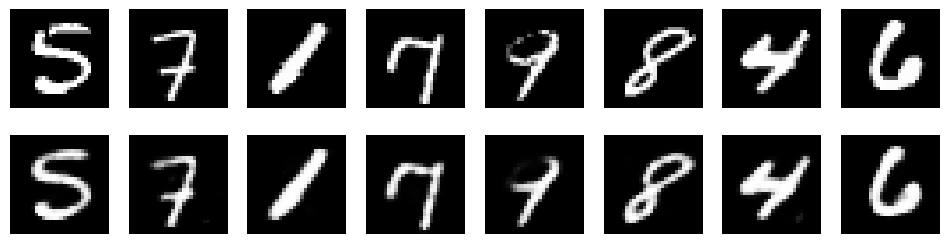

In [14]:
model.eval()

with torch.no_grad():
    x, _ = next(iter(train_loader))
    x = x.view(-1, 784).to(device)
    x_recons = model(x)

    n = 8
    plt.figure(figsize=(12, 3))

    for i in range(n):
        plt.subplot(2, n, i + 1)
        plt.imshow(x[i].view(28, 28).detach().cpu().numpy(), cmap="gray")
        plt.axis("off")

        plt.subplot(2, n, i + 1 + n)
        plt.imshow(x_recons[i].view(28, 28).detach().cpu().numpy(), cmap="gray")
        plt.axis("off")

    plt.show()

In [15]:
model.eval()

latents = []
labels = []

with torch.no_grad():
    for x, y in train_loader:
        x = x.view(-1, 784).to(device)
        z = model.encoder(x)

        latents.append(z.cpu())
        labels.append(y)

latents = torch.cat(latents, dim=0)
labels = torch.cat(labels, dim=0)

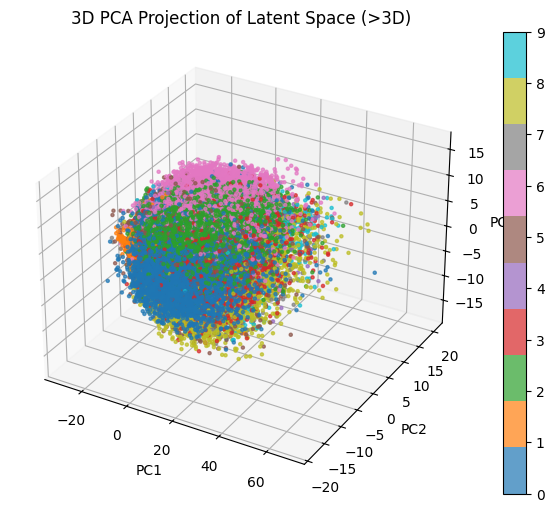

In [16]:
latent_dim = latents.shape[1]

Z = latents.detach().cpu().numpy()
y = labels.detach().cpu().numpy()

if latent_dim == 1:
    plt.figure(figsize=(8, 4))
    for digit in range(10):
        plt.hist(
            Z[y == digit].flatten(),
            bins=50,
            alpha=0.5,
            label=str(digit)
        )
    plt.xlabel("Latent value")
    plt.ylabel("Frequency")
    plt.title("1D Latent Distribution by Class")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 3))
    plt.scatter(Z.flatten(), y, s=5, alpha=0.5, c=y, cmap="tab10")
    plt.xlabel("Latent value")
    plt.ylabel("Digit class")
    plt.title("1D Latent Strip Plot")
    plt.colorbar(ticks=range(10))
    plt.show()

elif latent_dim == 2:
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        Z[:, 0], Z[:, 1],
        c=y, cmap="tab10",
        s=5, alpha=0.7
    )
    plt.xlabel("z1")
    plt.ylabel("z2")
    plt.title("2D Latent Space")
    plt.colorbar(scatter, ticks=range(10))
    plt.show()

elif latent_dim == 3:
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    scatter = ax.scatter(
        Z[:, 0], Z[:, 1], Z[:, 2],
        c=y, cmap="tab10",
        s=5, alpha=0.7
    )
    ax.set_xlabel("z1")
    ax.set_ylabel("z2")
    ax.set_zlabel("z3")
    ax.set_title("3D Latent Space")
    fig.colorbar(scatter, ticks=range(10))
    plt.show()

else:
    pca_dim = 3 if latent_dim >= 3 else 2
    pca = PCA(n_components=pca_dim)
    Z_pca = pca.fit_transform(Z)

    if pca_dim == 2:
        plt.figure(figsize=(8, 6))
        scatter = plt.scatter(
            Z_pca[:, 0], Z_pca[:, 1],
            c=y, cmap="tab10",
            s=5, alpha=0.7
        )
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.title("PCA Projection of Latent Space (>3D)")
        plt.colorbar(scatter, ticks=range(10))
        plt.show()
    else:
        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(111, projection="3d")
        scatter = ax.scatter(
            Z_pca[:, 0], Z_pca[:, 1], Z_pca[:, 2],
            c=y, cmap="tab10",
            s=5, alpha=0.7
        )
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.set_zlabel("PC3")
        ax.set_title("3D PCA Projection of Latent Space (>3D)")
        fig.colorbar(scatter, ticks=range(10))
        plt.show()

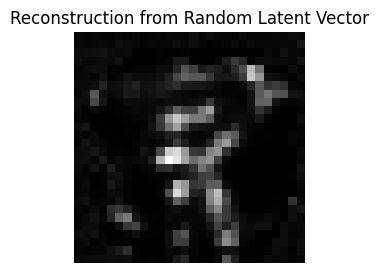

In [19]:
model.eval()

with torch.no_grad():
    latent_dim = latents.shape[1]
    z_random = torch.randn(1, latent_dim).to(device)

    x_generated = model.decoder(z_random)
    x_generated = x_generated.cpu().view(28, 28)

plt.figure(figsize=(3, 3))
plt.imshow(x_generated, cmap="gray")
plt.axis("off")
plt.title("Reconstruction from Random Latent Vector")
plt.show()